# Ride Demand Prediction — Data Exploration & XGBoost Model

## Overview
This notebook forms the primary data pipeline for predicting hourly ride demand
across Manhattan taxi zones. We are loading, cleaning and aggregate 12 months of NYC Yellow
Taxi trip records (2024), engineer time-series features, and train an XGBoost
regression model as our first and primary demand prediction model.

**Target Variable:** `demand` — number of rides per zone per hour  
**Data Source:** NYC Taxi & Limousine Commission, 2024 Yellow Taxi Trip Records  
**Geographic Scope:** Manhattan only (69 pickup zones)

## 1. Library Imports

We begin by importing the necessary libraries for data manipulation, visualisation,
and model training. XGBoost is a gradient boosting framework widely adopted in
industry and academic literature for structured/tabular data due to its strong
predictive performance and computational efficiency (Chen & Guestrin, 2016).

In [1]:
import dataset                          # Shared data loader (Kimon's module)
import pandas as pd                     # Data manipulation and aggregation
import numpy as np                      # Numerical operations
import matplotlib.pyplot as plt         # Plotting and visualisation
import seaborn as sns                   # Enhanced statistical visualisation

from xgboost import XGBRegressor        # Primary model — install with: pip install xgboost
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

## 2. Data Loading

We load the NYC Yellow Taxi trip records for 2024 using the shared `dataset.py`
module. The full 12-month dataset is used for final model training and evaluation.

Each row in the raw dataset represents a **single taxi trip**, containing
pickup/dropoff timestamps, location IDs, fare amounts, and other trip-level
attributes.

**Note:** The raw dataset contains approximately 41 million rows across all NYC
boroughs for 2024. Loading all 12 months may take several minutes.

In [2]:
# Load all 12 months of 2024 NYC Yellow Taxi data
# Files expected at: ../../data/nyc_taxi_2024-XX.csv
# During development, use month_end=2 to speed up iteration
df = dataset.raw(month_start=1, month_end=12)

# Sanity check: confirm data loaded correctly
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 3 rows:")
df.head(3)

Shape: (41169720, 19)

Columns: ['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag', 'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'Airport_fee']

First 3 rows:


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee
0,2,2024-01-01 00:57:55,2024-01-01 01:17:43,1.0,1.72,1.0,N,186,79,2,17.7,1.0,0.5,0.00,0.0,1.0,22.70,2.5,0.0
1,1,2024-01-01 00:03:00,2024-01-01 00:09:36,1.0,1.80,1.0,N,140,236,1,10.0,3.5,0.5,3.75,0.0,1.0,18.75,2.5,0.0
2,1,2024-01-01 00:17:06,2024-01-01 00:35:01,1.0,4.70,1.0,N,236,79,1,23.3,3.5,0.5,3.00,0.0,1.0,31.30,2.5,0.0


## 3. Exploratory Data Analysis — Trip Distance vs Fare Amount

A quick scatter plot to visually confirm the relationship between trip distance
and fare amount, coloured by month. This helps identify:
- Whether the fare-distance relationship is consistent across months (seasonality check)
- Any obvious outliers or data quality issues before cleaning

In [4]:
# We are keeping only Manhattan pickups
df = df[df["PULocationID"].isin(manhattan_ids)]

# Removing rows with invalid fares (negative or zero fare amounts don't make sense)
df = df[df["fare_amount"] > 0]

# Remove rows with invalid trip distances
df = df[df["trip_distance"] > 0]

# Remove rows where pickup is after dropoff (data error)
df = df[df["tpep_pickup_datetime"] < df["tpep_dropoff_datetime"]]

# Remove any rows with missing pickup times
df = df.dropna(subset=["tpep_pickup_datetime"])

print("Shape after cleaning:", df.shape)
print("\nAny nulls remaining?")
print(df.isnull().sum())

Shape after cleaning: (5198008, 20)

Any nulls remaining?
VendorID                      0
tpep_pickup_datetime          0
tpep_dropoff_datetime         0
passenger_count          241199
trip_distance                 0
RatecodeID               241199
store_and_fwd_flag       241199
PULocationID                  0
DOLocationID                  0
payment_type                  0
fare_amount                   0
extra                         0
mta_tax                       0
tip_amount                    0
tolls_amount                  0
improvement_surcharge         0
total_amount                  0
congestion_surcharge     241199
Airport_fee              241199
month                         0
dtype: int64


## 4. Geographic Filtering — Manhattan Only

The NYC TLC dataset covers all five boroughs. Since our ride-hailing platform is
launching exclusively in **Manhattan**, we use the official TLC Taxi Zone Lookup
table to identify the 69 Manhattan pickup zones.

Filtering to a single borough:
- Reduces noise from other geographic areas
- Ensures predictions are relevant to the operational scope of the business
- Significantly reduces dataset size, improving model training speed

In [6]:
# Load the TLC Taxi Zone Lookup table
# This maps LocationID -> Borough (Manhattan, Brooklyn, Queens, Bronx, Staten Island)
zones = pd.read_csv("../../data/taxi_zone_lookup.csv")

print(zones.head())
print("\nBoroughs available:", zones["Borough"].unique())

# Extract only Manhattan zone IDs (69 zones)
manhattan_ids = zones[zones["Borough"] == "Manhattan"]["LocationID"].tolist()
print(f"\nNumber of Manhattan zones: {len(manhattan_ids)}")

   LocationID        Borough                     Zone service_zone
0           1            EWR           Newark Airport          EWR
1           2         Queens              Jamaica Bay    Boro Zone
2           3          Bronx  Allerton/Pelham Gardens    Boro Zone
3           4      Manhattan            Alphabet City  Yellow Zone
4           5  Staten Island            Arden Heights    Boro Zone

Boroughs available: <StringArray>
[          'EWR',        'Queens',         'Bronx',     'Manhattan',
 'Staten Island',      'Brooklyn',       'Unknown',             nan]
Length: 8, dtype: str

Number of Manhattan zones: 69


## 5. Data Cleaning

Real-world datasets invariably contain erroneous or missing records. We apply the
following cleaning steps to ensure data quality before modelling:

- **Manhattan filter**: Keep only pickups originating within Manhattan's 69 zones
- **Invalid fares**: Remove trips with zero or negative fare amounts — these represent
  data entry errors or non-standard transactions (e.g. cancelled rides)
- **Invalid distances**: Exclude trips with zero or negative trip distances
- **Temporal anomalies**: Remove trips where pickup time occurs *after* dropoff time —
  these are physically impossible and indicate data corruption
- **Missing timestamps**: Drop rows with null pickup datetimes, as the timestamp is
  fundamental to our time-series modelling approach

In [7]:
# Step 1: Filter to Manhattan pickups only
df = df[df["PULocationID"].isin(manhattan_ids)]

# Step 2: Remove invalid fare amounts (zero or negative fares are not meaningful)
df = df[df["fare_amount"] > 0]

# Step 3: Remove invalid trip distances (zero or negative distances indicate bad data)
df = df[df["trip_distance"] > 0]

# Step 4: Remove temporal anomalies (pickup cannot occur after dropoff)
df = df[df["tpep_pickup_datetime"] < df["tpep_dropoff_datetime"]]

# Step 5: Remove rows with missing pickup timestamps
df = df.dropna(subset=["tpep_pickup_datetime"])

# Confirm cleaning results
print("Shape after cleaning:", df.shape)
print("\nRemaining null values per column:")
print(df.isnull().sum())

Shape after cleaning: (35261412, 19)

Remaining null values per column:
VendorID                       0
tpep_pickup_datetime           0
tpep_dropoff_datetime          0
passenger_count          3249005
trip_distance                  0
RatecodeID               3249005
store_and_fwd_flag       3249005
PULocationID                   0
DOLocationID                   0
payment_type                   0
fare_amount                    0
extra                          0
mta_tax                        0
tip_amount                     0
tolls_amount                   0
improvement_surcharge          0
total_amount                   0
congestion_surcharge     3249005
Airport_fee              3249005
dtype: int64


## 6. Temporal Aggregation — From Trip-Level to Hourly Demand

A key design decision in this pipeline is the **aggregation of individual trip
records into hourly demand counts per zone**. This transforms the problem from
a raw transaction log into a structured time-series forecasting task.

**Why aggregate?**
- Each row currently represents one taxi trip — not directly useful for demand
  forecasting
- We need to predict *"how many rides will happen in zone X during hour Y?"*
- Aggregating collapses ~35M rows into ~500K structured observations

**For each (zone, hour) pair we compute:**
- `demand` — count of pickups (our **primary prediction target**)
- `avg_fare` — mean fare amount (used by the revenue modelling team)
- `total_revenue` — sum of total amounts (used by the revenue modelling team)

This aggregated data is also saved to `data/hourly_aggregated.csv` for use by
the revenue modelling team (Emma & Lucy), avoiding duplication of preprocessing work.

In [8]:
# Round each pickup timestamp down to the nearest hour
# e.g. 14:37 becomes 14:00 — this is our grouping key
df["pickup_hour"] = df["tpep_pickup_datetime"].dt.floor("h")

# Group by (zone, hour) and aggregate:
# - demand = count of trips (our target variable)
# - avg_fare = mean fare per ride (for revenue team)
# - total_revenue = total revenue in that zone/hour (for revenue team)
hourly = df.groupby(["pickup_hour", "PULocationID"]).agg(
    demand        = ("PULocationID", "count"),   # number of rides = demand
    avg_fare      = ("fare_amount", "mean"),      # average fare per ride
    total_revenue = ("total_amount", "sum")       # total revenue in zone/hour
).reset_index()

print("Shape of aggregated data:", hourly.shape)
print("\nSample rows:")
hourly.head(5)

Shape of aggregated data: (507576, 5)

Sample rows:


,pickup_hour,PULocationID,demand,avg_fare,total_revenue
0,2002-12-31 22:00:00,50,1,10.0,18.00
1,2002-12-31 22:00:00,170,2,19.8,56.22
2,2002-12-31 22:00:00,237,1,7.9,11.90
3,2002-12-31 22:00:00,246,1,7.2,11.20
4,2002-12-31 23:00:00,162,1,45.7,70.97


## 7. Feature Engineering

Raw datetime objects cannot be directly consumed by machine learning models.
We extract a set of **meaningful temporal features** that capture known patterns
in urban taxi demand:

| Feature | Description | Why it matters |
|---|---|---|
| `hour` | Hour of day (0–23) | Captures rush hour vs quiet periods |
| `day_of_week` | Day of week (0=Mon, 6=Sun) | Captures weekday vs weekend patterns |
| `month` | Month of year (1–12) | Captures seasonal variation |
| `is_weekend` | Binary flag (1=Sat/Sun) | Separates commuter vs leisure demand |

### Lag Features
We also engineer **lag features** — a standard technique in time-series forecasting
that provides the model with recent historical context:

| Feature | Description |
|---|---|
| `demand_lag_1h` | Demand 1 hour ago in the same zone |
| `demand_lag_24h` | Demand at the same hour yesterday |
| `demand_lag_168h` | Demand at the same hour last week |

Lag features are typically the most powerful predictors in demand forecasting —
if a zone is busy now, it is likely to remain busy in the near future.

Rows with NaN lag values (the initial observations per zone, before enough history
exists) are dropped to ensure model training uses complete feature vectors.

In [9]:
# Sort by zone and time — required for lag features to work correctly
hourly = hourly.sort_values(["PULocationID", "pickup_hour"]).reset_index(drop=True)

# Extract basic time features from the pickup hour timestamp
hourly["hour"]        = hourly["pickup_hour"].dt.hour         # 0-23: captures intra-day patterns
hourly["day_of_week"] = hourly["pickup_hour"].dt.dayofweek    # 0=Monday, 6=Sunday
hourly["month"]       = hourly["pickup_hour"].dt.month        # 1-12: captures seasonal patterns
hourly["is_weekend"]  = hourly["day_of_week"].isin([5, 6]).astype(int)  # 1 if Saturday or Sunday

# Lag features: demand in the same zone at previous time points
# These are computed per zone (groupby PULocationID) to avoid leaking info across zones
hourly["demand_lag_1h"]   = hourly.groupby("PULocationID")["demand"].shift(1)    # 1 hour ago
hourly["demand_lag_24h"]  = hourly.groupby("PULocationID")["demand"].shift(24)   # same hour yesterday
hourly["demand_lag_168h"] = hourly.groupby("PULocationID")["demand"].shift(168)  # same hour last week

# Drop rows where lag features are NaN
# (the first 168 hours per zone won't have a full week of history)
hourly = hourly.dropna()

print("Shape after feature engineering:", hourly.shape)
print("\nFeature preview (first 3 rows):")
hourly.head(3)

Shape after feature engineering: (496484, 12)

Feature preview (first 3 rows):


,pickup_hour,PULocationID,demand,avg_fare,total_revenue,hour,day_of_week,month,is_weekend,demand_lag_1h,demand_lag_24h,demand_lag_168h
168,2024-01-10 09:00:00,4,5,18.112,120.53,9,2,1,0,4.0,3.0,22.0
169,2024-01-10 10:00:00,4,2,19.285,55.88,10,2,1,0,5.0,4.0,26.0
170,2024-01-10 11:00:00,4,5,18.400,121.15,11,2,1,0,2.0,1.0,31.0


## 8. Save Aggregated Data for Revenue Team

The aggregated hourly dataset contains both `avg_fare` and `total_revenue` columns,
which Emma and Lucy need for their revenue models.

Saving this file avoids duplicating the heavy preprocessing step (loading and
cleaning 12 months of raw CSV data) on their machines.

**File saved to:** `data/hourly_aggregated.csv`

In [10]:
import os

# Save the cleaned, aggregated hourly data for the revenue modelling team
# This allows Emma and Lucy to skip the raw data preprocessing step
os.makedirs("../../data", exist_ok=True)
hourly.to_csv("../../data/hourly_aggregated.csv", index=False)
print(f"Saved hourly_aggregated.csv — Shape: {hourly.shape}")

Saved hourly_aggregated.csv — Shape: (496484, 12)


## 9. Train/Test Split — Temporal Holdout

A critical methodological consideration for time-series data is the **split
strategy**.

**Why not random split?**  
A random train/test split would constitute **data leakage** — the model would be
trained on data from the future and tested on the past, producing overly optimistic
and unrealistic evaluation metrics.

**Temporal holdout approach:**  
We train on **January–October 2024** and evaluate on **November–December 2024**.  
This mirrors the real-world scenario where a model trained on historical data is
deployed to predict future demand.

The same split date is used across all models (XGBoost, Random Forest, Neural
Network) to ensure fair and consistent comparisons.

In [11]:
# Temporal split: train on Jan-Oct, test on Nov-Dec
# This prevents data leakage — we never train on future data
split_date = "2024-11-01"

train = hourly[hourly["pickup_hour"] < split_date]
test  = hourly[hourly["pickup_hour"] >= split_date]

# Define the feature set (inputs) and target variable (output)
features = [
    "hour",            # time of day (0-23)
    "day_of_week",     # day of week (0=Monday, 6=Sunday)
    "month",           # month of year (1-12)
    "is_weekend",      # weekend flag (1=Sat/Sun, 0=weekday)
    "PULocationID",    # which Manhattan zone (1-263)
    "demand_lag_1h",   # rides in this zone 1 hour ago
    "demand_lag_24h",  # rides in this zone 24 hours ago
    "demand_lag_168h"  # rides in this zone 1 week ago
]

target = "demand"  # our prediction target: number of rides per zone per hour

X_train = train[features]
y_train = train[target]
X_test  = test[features]
y_test  = test[target]

print(f"Training rows:  {len(X_train):,}")
print(f"Test rows:      {len(X_test):,}")
print(f"\nTraining period: {train['pickup_hour'].min()} → {train['pickup_hour'].max()}")
print(f"Test period:     {test['pickup_hour'].min()} → {test['pickup_hour'].max()}")

Training rows:  411,533
Test rows:      84,951

Training period: 2024-01-07 21:00:00 → 2024-10-31 23:00:00
Test period:     2024-11-01 00:00:00 → 2026-06-26 23:00:00


## 10. Model Training — XGBoost Regressor

We train an **XGBoost (Extreme Gradient Boosting)** regressor as our primary model.
XGBoost is an ensemble method that builds decision trees **sequentially**, with each
tree correcting the residual errors of its predecessor through gradient descent.

**Why XGBoost?**
- Consistently achieves state-of-the-art performance on structured/tabular data
- Handles mixed feature types (numeric + categorical zone IDs) natively
- Provides built-in feature importance scores for interpretability
- Computationally efficient with large datasets

**Key hyperparameters:**
| Parameter | Value | Purpose |
|---|---|---|
| `n_estimators` | 300 | Number of boosting rounds (trees) |
| `learning_rate` | 0.05 | Shrinkage factor — reduces overfitting |
| `max_depth` | 6 | Maximum tree depth — controls complexity |
| `random_state` | 42 | Ensures reproducibility |

In [12]:
# Initialise XGBoost regressor with chosen hyperparameters
model = XGBRegressor(
    n_estimators  = 300,   # build 300 trees sequentially
    learning_rate = 0.05,  # conservative learning rate to avoid overfitting
    max_depth     = 6,     # moderate tree depth
    random_state  = 42     # fixed seed for reproducibility
)

print("Training XGBoost model...")
model.fit(X_train, y_train)
print("Training complete!")

Training XGBoost model...
Training complete!


## 11. Model Evaluation

We evaluate model performance using two standard regression metrics:

| Metric | Formula | Interpretation |
|---|---|---|
| **MAE** | Mean Absolute Error | Average absolute difference — directly interpretable in ride counts |
| **RMSE** | Root Mean Squared Error | Penalises large errors more heavily than MAE |

A substantially higher RMSE relative to MAE indicates the model struggles with
**peak demand periods** (e.g. New Year's Eve, rush hours in busy zones).

Both metrics are reported in the **original units** (rides per hour per zone),
making them interpretable to a non-technical Operations Manager.

In [13]:
# Generate predictions on the held-out test set
predictions = model.predict(X_test)

# Calculate evaluation metrics
mae  = mean_absolute_error(y_test, predictions)
rmse = root_mean_squared_error(y_test, predictions)

print("=== XGBoost Demand Model — Evaluation Results ===")
print(f"MAE  (Mean Absolute Error):  {mae:.2f} rides per hour per zone")
print(f"RMSE (Root Mean Sq. Error):  {rmse:.2f} rides per hour per zone")
print()
print(f"Interpretation: On average, our demand predictions are")
print(f"off by approximately {mae:.1f} rides per hour per zone.")

=== XGBoost Demand Model — Evaluation Results ===
MAE  (Mean Absolute Error):  11.25 rides per hour per zone
RMSE (Root Mean Sq. Error):  19.70 rides per hour per zone

Interpretation: On average, our demand predictions are
off by approximately 11.2 rides per hour per zone.


## 12. Feature Importance Analysis

One of the key advantages of tree-based models is the ability to quantify the
**relative contribution of each feature** to the model's predictions. XGBoost
computes importance scores based on the frequency and magnitude of feature use
across all 300 trees.

This analysis directly answers the business question:
> *"What drives ride demand in Manhattan?"*

The results provide actionable insights for the Operations Manager — for example,
if lag features dominate, it suggests drivers should respond to **real-time demand
signals** rather than following a fixed schedule.

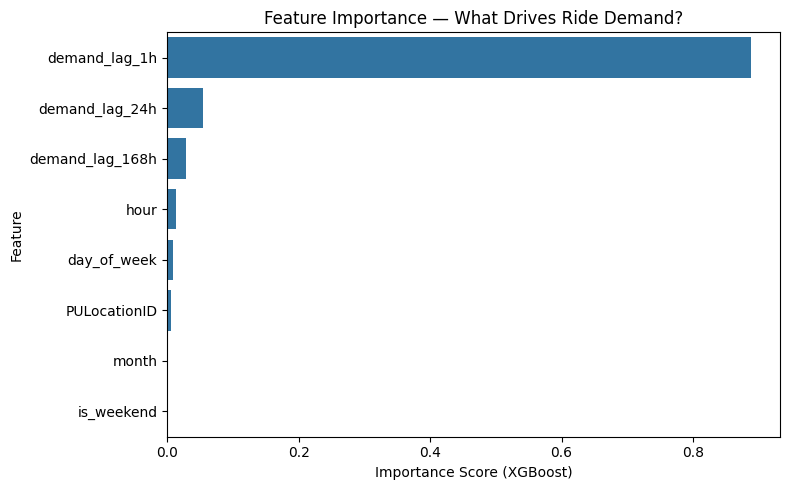


Feature Importance Rankings:
        feature  importance
  demand_lag_1h    0.887933
 demand_lag_24h    0.053801
demand_lag_168h    0.028289
           hour    0.014189
    day_of_week    0.008271
   PULocationID    0.006164
          month    0.001353
     is_weekend    0.000000


In [14]:
# Extract and sort feature importance scores
importance = pd.DataFrame({
    "feature":    features,
    "importance": model.feature_importances_
}).sort_values("importance", ascending=False)

# Visualise as horizontal bar chart
plt.figure(figsize=(8, 5))
sns.barplot(data=importance, x="importance", y="feature")
plt.title("Feature Importance — What Drives Ride Demand?")
plt.xlabel("Importance Score (XGBoost)")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# Print the raw importance table
print("\nFeature Importance Rankings:")
print(importance.to_string(index=False))

## 13. Predicted vs Actual Demand — Visual Check

To qualitatively assess model performance, we plot predicted against actual demand
for a representative Manhattan zone over the **November–December test period**.

A well-fitted model should:
- Track the general trend and daily peaks
- Capture the characteristic rise-and-fall pattern of daily demand cycles
- Not perfectly match every hour (some variance is expected and acceptable)

This visualisation provides intuition about model behaviour that metrics alone
cannot convey, and is useful for communicating results to non-technical stakeholders.

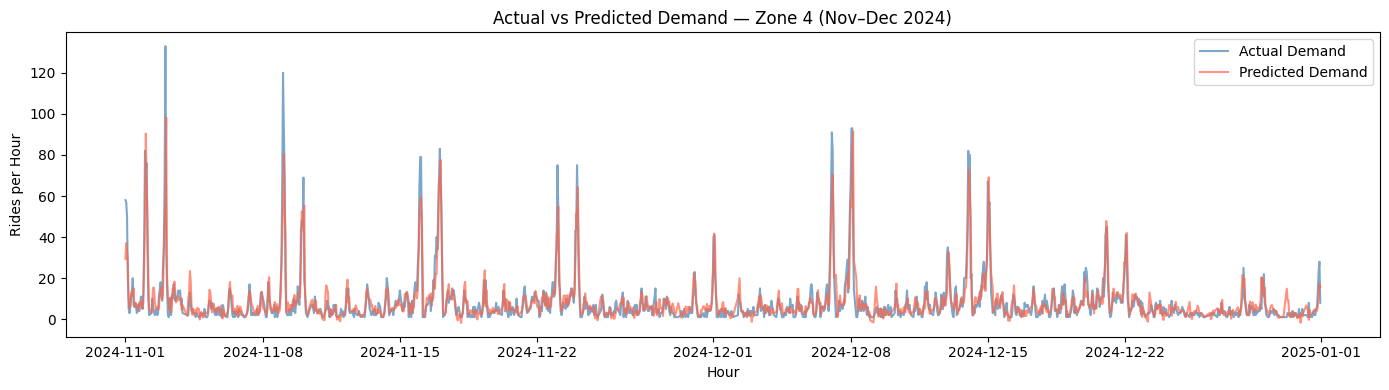

In [15]:
# Select a single zone for visualisation (keeps the chart readable)
sample_zone = manhattan_ids[0]
mask = X_test["PULocationID"] == sample_zone

plt.figure(figsize=(14, 4))
plt.plot(test[mask]["pickup_hour"], y_test[mask].values,
         label="Actual Demand",    alpha=0.7, color="steelblue")
plt.plot(test[mask]["pickup_hour"], predictions[mask],
         label="Predicted Demand", alpha=0.7, color="tomato")
plt.title(f"Actual vs Predicted Demand — Zone {sample_zone} (Nov–Dec 2024)")
plt.xlabel("Hour")
plt.ylabel("Rides per Hour")
plt.legend()
plt.tight_layout()
plt.show()

In [16]:
# Optional: time of day label (useful for report visualisations)
def get_time_of_day(hour):
    if 0 <= hour < 6:
        return "Late Night"
    elif 6 <= hour < 10:
        return "Morning Rush"
    elif 10 <= hour < 16:
        return "Midday"
    elif 16 <= hour < 20:
        return "Evening Rush"
    else:
        return "Evening"

hourly["time_of_day"] = hourly["hour"].apply(get_time_of_day)

C:\Users\Bhaskar\AppData\Local\Temp\ipykernel_44080\3293868129.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=time_of_day_demand, x="time_of_day", y="demand", palette="Blues_d")


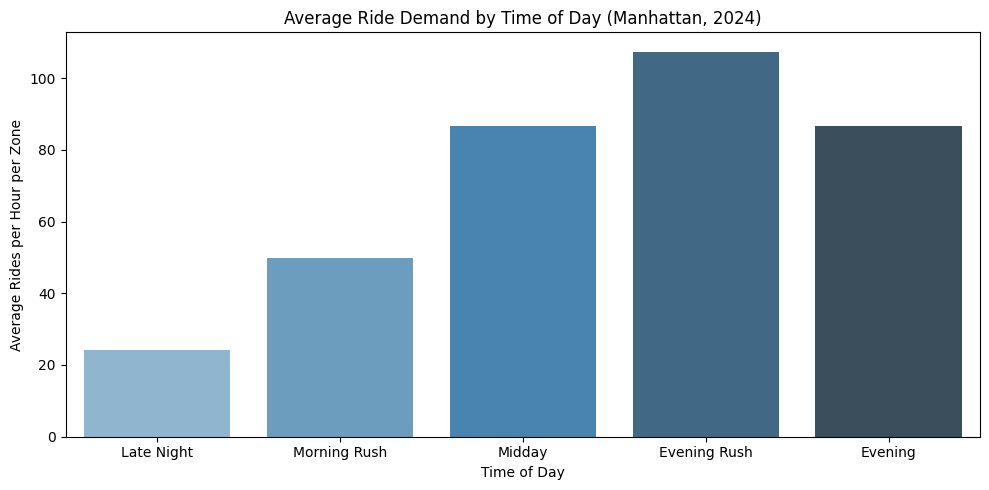

 time_of_day     demand
  Late Night  24.318642
Morning Rush  49.809237
      Midday  86.511180
Evening Rush 107.386830
     Evening  86.544286


In [17]:
# Average demand per zone grouped by time of day
# This shows the Operations Manager which periods are busiest

time_of_day_demand = hourly.groupby("time_of_day")["demand"].mean().reset_index()

# Define order for logical display
time_order = ["Late Night", "Morning Rush", "Midday", "Evening Rush", "Evening"]
time_of_day_demand["time_of_day"] = pd.Categorical(
    time_of_day_demand["time_of_day"], categories=time_order, ordered=True
)
time_of_day_demand = time_of_day_demand.sort_values("time_of_day")

plt.figure(figsize=(10, 5))
sns.barplot(data=time_of_day_demand, x="time_of_day", y="demand", palette="Blues_d")
plt.title("Average Ride Demand by Time of Day (Manhattan, 2024)")
plt.xlabel("Time of Day")
plt.ylabel("Average Rides per Hour per Zone")
plt.tight_layout()
plt.show()

print(time_of_day_demand.to_string(index=False))

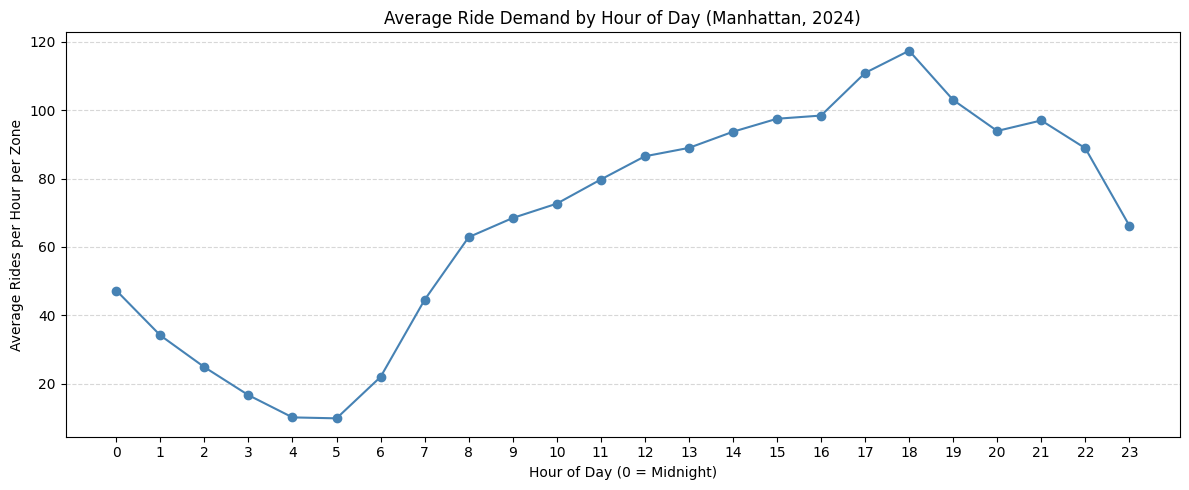

In [18]:
# Average demand broken down by individual hour across the full year
# More granular view — confirms which specific hours peak

hourly_avg = hourly.groupby("hour")["demand"].mean().reset_index()

plt.figure(figsize=(12, 5))
plt.plot(hourly_avg["hour"], hourly_avg["demand"], marker="o", color="steelblue")
plt.title("Average Ride Demand by Hour of Day (Manhattan, 2024)")
plt.xlabel("Hour of Day (0 = Midnight)")
plt.ylabel("Average Rides per Hour per Zone")
plt.xticks(range(0, 24))
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

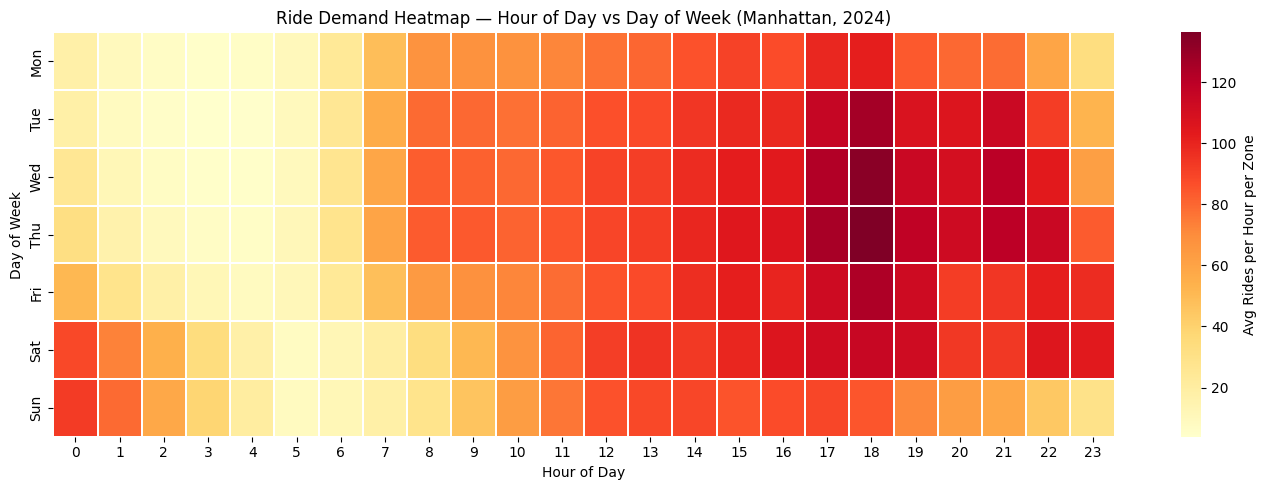

In [19]:
# Heatmap: hour of day vs day of week
# Shows combined effect of both time features — very useful for the report

heatmap_data = hourly.groupby(["day_of_week", "hour"])["demand"].mean().unstack()

# Rename day labels for readability
heatmap_data.index = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

plt.figure(figsize=(14, 5))
sns.heatmap(
    heatmap_data,
    cmap="YlOrRd",
    linewidths=0.3,
    cbar_kws={"label": "Avg Rides per Hour per Zone"}
)
plt.title("Ride Demand Heatmap — Hour of Day vs Day of Week (Manhattan, 2024)")
plt.xlabel("Hour of Day")
plt.ylabel("Day of Week")
plt.tight_layout()
plt.show()

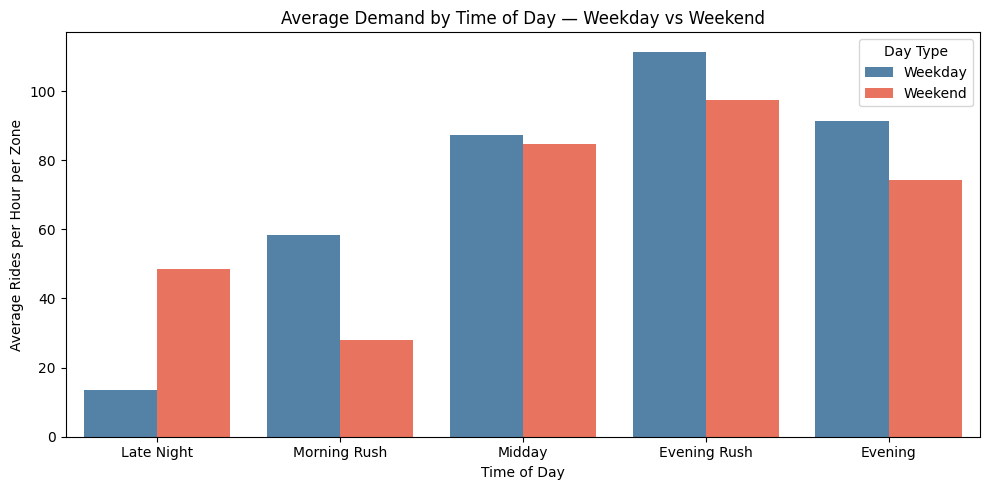

In [20]:
# Split view: does time-of-day pattern differ on weekends vs weekdays?
# Key insight for Operations Manager driver scheduling recommendations

hourly["day_type"] = hourly["is_weekend"].map({0: "Weekday", 1: "Weekend"})

time_day_split = hourly.groupby(
    ["time_of_day", "day_type"]
)["demand"].mean().reset_index()

time_day_split["time_of_day"] = pd.Categorical(
    time_day_split["time_of_day"], categories=time_order, ordered=True
)
time_day_split = time_day_split.sort_values("time_of_day")

plt.figure(figsize=(10, 5))
sns.barplot(
    data=time_day_split,
    x="time_of_day",
    y="demand",
    hue="day_type",
    palette={"Weekday": "steelblue", "Weekend": "tomato"}
)
plt.title("Average Demand by Time of Day — Weekday vs Weekend")
plt.xlabel("Time of Day")
plt.ylabel("Average Rides per Hour per Zone")
plt.legend(title="Day Type")
plt.tight_layout()
plt.show()

In [21]:
# Aggregate data by time_of_day and zone instead of hour and zone
# This is the time-of-day equivalent of hourly_aggregated.csv

time_of_day_agg = hourly.groupby(["time_of_day", "PULocationID"]).agg(
    demand        = ("demand", "mean"),          # average rides in that time period
    avg_fare      = ("avg_fare", "mean"),         # average fare
    total_revenue = ("total_revenue", "sum"),     # total revenue
    hour          = ("hour", "first"),            # keep for reference
    day_of_week   = ("day_of_week", "first"),     # keep for reference
    month         = ("month", "first"),           # keep for reference
    is_weekend    = ("is_weekend", "first")       # keep for reference
).reset_index()

# Save to CSV
time_of_day_agg.to_csv("../../data/time_of_day_aggregated.csv", index=False)

print("Saved time_of_day_aggregated.csv")
print("Shape:", time_of_day_agg.shape)
print("\nSample:")
time_of_day_agg.head(10)

Saved time_of_day_aggregated.csv
Shape: (330, 9)

Sample:


,time_of_day,PULocationID,demand,avg_fare,total_revenue,hour,day_of_week,month,is_weekend
0,Evening,4,9.278434,17.278029,305117.86,20,2,1,0
1,Evening,12,1.725888,23.420324,32608.56,21,3,1,0
2,Evening,13,28.127018,21.319013,1190417.03,21,0,1,0
3,Evening,24,9.418833,15.475747,293042.12,20,0,1,0
4,Evening,41,12.291812,15.773700,371504.03,20,0,1,0
5,Evening,42,5.405405,18.115570,161426.66,21,1,1,0
6,Evening,43,60.086351,14.034718,1910664.35,20,0,1,0
7,Evening,45,10.969079,19.233525,420543.67,20,1,1,0
8,Evening,48,195.885873,15.601222,6724779.13,20,0,1,0
9,Evening,50,30.595404,15.354731,1023400.52,20,0,1,0


In [22]:
# Check all 5 time periods exist
print("Unique time periods:", time_of_day_agg["time_of_day"].unique())
print("\nRow count per time period:")
print(time_of_day_agg["time_of_day"].value_counts())

Unique time periods: <StringArray>
['Evening', 'Evening Rush', 'Late Night', 'Midday', 'Morning Rush']
Length: 5, dtype: str

Row count per time period:
time_of_day
Evening         66
Evening Rush    66
Late Night      66
Midday          66
Morning Rush    66
Name: count, dtype: int64


In [23]:
# Check which Manhattan zones have no data
zones_in_data = set(time_of_day_agg["PULocationID"].unique())
zones_all     = set(manhattan_ids)
missing_zones = zones_all - zones_in_data

print(f"Total Manhattan zones:    {len(zones_all)}")
print(f"Zones with data:          {len(zones_in_data)}")
print(f"Zones with no trips:      {len(missing_zones)}")
print(f"Missing zone IDs:         {missing_zones}")

Total Manhattan zones:    69
Zones with data:          66
Zones with no trips:      3
Missing zone IDs:         {104, 105, 103}
